# Regresión Lineal con ecosistema científico estándar de Python

Guía optimizada para resolver el mismo caso de estudio utilizando el ecosistema científico estándar de Python: **Pandas** para la manipulación de datos, **NumPy** para el cálculo matemático vectorizado y **Matplotlib** para la visualización del modelo.

## Caso de Estudio: Predicción de Calificaciones basadas en Horas de Estudio (Librerías Científicas)

Este caso analiza cómo el tiempo dedicado a la preparación influye en el rendimiento académico. El objetivo es automatizar el cálculo de la regresión lineal simple y la evaluación de bondad de ajuste de forma eficiente, eliminando los ciclos lógicos manuales (`for`) mediante operaciones matriciales y vectorizadas.

## Documentación del Dataset

El archivo de entrada `datos_estudio.csv` debe estar guardado en la misma ruta del script con la siguiente estructura:

* `horas_estudio`: Variable independiente (X). Medida en horas continuas.
* `calificacion`: Variable dependiente (Y). Puntaje final del examen (escala 0-10).

## Bloque 1: Carga y Exploración de Datos con Pandas

**Explicación:**

Utilizamos `pandas` para leer el archivo CSV en un objeto estructurado llamado `DataFrame`. La función `pd.read_csv()` gestiona automáticamente la fila de encabezados y los tipos de datos de forma interna. Extraemos las columnas como series de datos y obtenemos el tamaño del set de datos con la propiedad `.shape[0]`.

In [7]:
import pandas as pd

# Cargar el archivo CSV en un DataFrame de Pandas
df = pd.read_csv('datos_estudio.csv')

# Extraer las variables como series de datos
X = df['horas_estudio']
Y = df['calificacion']

# Obtener el número total de observaciones (n)
n = df.shape[0]

print("--- DATOS CARGADOS CON PANDAS ---")
print(df)
print(f"\nNúmero total de observaciones (n): {n}")

--- DATOS CARGADOS CON PANDAS ---
   horas_estudio  calificacion
0              1             2
1              2             5
2              4             5
3              5             8

Número total de observaciones (n): 4


## Bloque 2: Operaciones Vectorizadas con NumPy (Promedios y Coeficientes)

**Explicación:**

En lugar de iterar dato por dato, `numpy` permite aplicar operaciones matemáticas a todo el vector al mismo tiempo. Aquí aplicamos las fórmulas principales de la regresión lineal:

* **Promedios:** x̄ = mean(X) y ȳ = mean(Y)

* **Pendiente (b₁):** Se calcula restando de forma directa el promedio a todo el vector y multiplicando los resultados:

$$b_1 = \frac{\sum (X - \bar{x})(Y - \bar{y})}{\sum (X - \bar{x})^2}$$

* **Intercepto (b₀):** $$b_0 = \bar{y} - b_1 \bar{x}$$

In [8]:
import numpy as np

# Calcular los promedios de forma vectorizada
promedio_x = np.mean(X)
promedio_y = np.mean(Y)

# Aplicar las fórmulas matemáticas elementales sobre los arreglos de NumPy
numerador_b1 = np.sum((X - promedio_x) * (Y - promedio_y))
denominador_b1 = np.sum((X - promedio_x) ** 2)

# Determinar los coeficientes del modelo lineal
b1 = numerador_b1 / denominador_b1
b0 = promedio_y - (b1 * promedio_x)

print(f"Centro de gravedad del modelo: ({promedio_x:.2f}, {promedio_y:.2f})")
print(f"Pendiente calculada (b1): {b1:.2f}")
print(f"Intercepto calculado (b0): {b0:.2f}")

Centro de gravedad del modelo: (3.00, 5.00)
Pendiente calculada (b1): 1.20
Intercepto calculado (b0): 1.40


## Bloque 3: Evaluación del Modelo (Predicciones, Residuos y Bondad de Ajuste)

**Explicación:**

Calculamos el vector completo de predicciones (Ŷ) ejecutando la ecuación de la recta ŷ = b₀ + b₁ x. Posteriormente evaluamos la precisión del modelo aplicando las siguientes fórmulas matemáticas nativas integradas con funciones algebraicas de NumPy:

* **Suma de Cuadrados del Error:** $\text{SCE} = \sum (Y - \hat{Y})^2$ (Mide la distancia al cuadrado de los puntos reales a la recta).

* **Suma Total de Cuadrados:** $\text{STC} = \sum (Y - \bar{y})^2$ (Mide la variabilidad total de las notas).

* **Error Estándar de la Estimación:** $S_e = \sqrt{\frac{\text{SCE}}{n - 2}}$

* **Coeficiente de Determinación:** $R^2 = 1 - \frac{\text{SCE}}{\text{STC}}$

* **Coeficiente de Pearson:** $r = \sqrt{R^2}$

In [9]:
# Generar el vector completo de valores estimados de forma lineal
Y_pred = b0 + b1 * X

# Calcular métricas de variabilidad utilizando la suma vectorizada (np.sum)
sce = np.sum((Y - Y_pred) ** 2)
stc = np.sum((Y - promedio_y) ** 2)

# Aplicar las fórmulas métricas de error y correlación
se = np.sqrt(sce / (n - 2))
r_cuadrado = 1 - (sce / stc)
r_pearson = np.sqrt(r_cuadrado)

print(f"Suma de Residuos Cuadráticos (SCE): {sce:.2f}")
print(f"Error Estándar del Modelo (Se): {se:.2f}")
print(f"Porcentaje de Varianza Explicada (R²): {r_cuadrado * 100:.1f}%")
print(f"Fuerza de Relación Lineal (r de Pearson): {r_pearson:.3f}")

Suma de Residuos Cuadráticos (SCE): 3.60
Error Estándar del Modelo (Se): 1.34
Porcentaje de Varianza Explicada (R²): 80.0%
Fuerza de Relación Lineal (r de Pearson): 0.894


## Bloque 4: Construcción del Gráfico de Dispersión y Línea de Regresión

**Explicación:**

En este bloque usamos `matplotlib.pyplot` para plasmar los datos visualmente. Creamos un gráfico bidimensional donde los puntos reales se grafican con `plt.scatter()` y la línea ajustada por el modelo se traza usando `plt.plot()`. Se añaden etiquetas a los ejes, leyendas descriptivas y una cuadrícula de fondo para facilitar la lectura del margen de error.

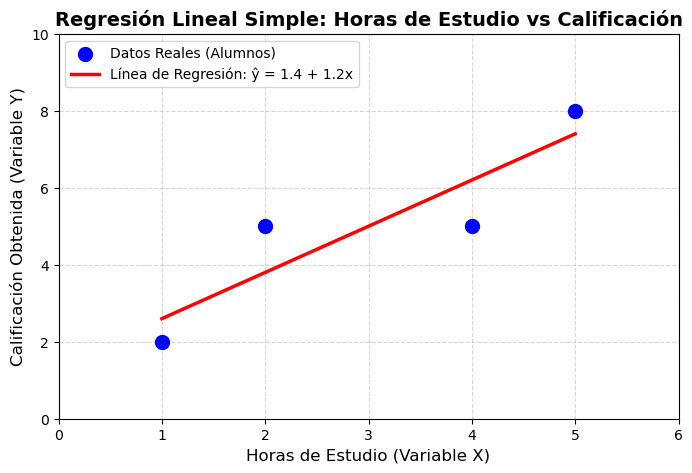

In [ ]:
import matplotlib.pyplot as plt

# Crear una figura para visualizar el modelo
plt.figure(figsize=(8, 5))

# Dibujar los datos reales observados en el CSV (puntos dispersos)
plt.scatter(X, Y, color='blue', label='Datos Reales (Alumnos)', s=100, zorder=5)

# Dibujar la recta de regresión lineal generada por nuestras fórmulas
plt.plot(X, Y_pred, color='red', linewidth=2.5, label=f'Línea de Regresión: ŷ = {b0:.1f} + {b1:.1f}x')

# Personalizar el entorno del gráfico estadístico
plt.title('Regresión Lineal Simple: Horas de Estudio vs Calificación', fontsize=14, fontweight='bold')
plt.xlabel('Horas de Estudio (Variable X)', fontsize=12)
plt.ylabel('Calificación Obtenida (Variable Y)', fontsize=12)
plt.xlim(0, 6)
plt.ylim(0, 10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper left')

# Mostrar el gráfico en pantalla
plt.show()

## Tabla Resumen del Modelo de Regresión Lineal

| Indicador | Nombre Técnico | Valor Numérico | Implementación y Aplicación en Código |
|---|---|---|---|
| **b₁** | Pendiente | **1.20** | Multiplica al vector `X` definiendo la inclinación o ritmo de crecimiento en el examen. |
| **b₀** | Intercepto | **1.40** | Constante que establece el origen o punto de corte vertical de la recta si `X = 0`. |
| **$S_e$** | Error Estándar | **1.34** | Determina que el error típico al predecir una nota usando el script es de ± 1.34. |
| **R²** | Coeficiente de Determinación | **0.80** | Evaluado mediante `1 - (sce / stc)`. Certifica una precisión del **80%** en la predicción. |
| **r** | Correlación de Pearson | **0.894** | Calculado con `np.sqrt(r_cuadrado)`. Expresa una relación positiva sumamente fuerte. |

## Resumen Técnico de todo lo aplicado

1. **Abstracción de Datos:** Gracias a Pandas, la lectura del set de datos se simplificó a una única instrucción de código estructurando la tabla nativa con indexación directa por nombre de columna.
2. **Eficiencia Vectorizada:** Al utilizar NumPy, se descartó el uso de ciclos complejos. Los cálculos aritméticos en las fórmulas matemáticas se ejecutan de manera simultánea en la memoria de la computadora mediante operaciones sobre vectores (`arrays`).
3. **Evaluación Visual Completa:** La incorporación de Matplotlib permitió validar el comportamiento del modelo de forma empírica, logrando contrastar las distancias verticales existentes entre los datos empíricos de los alumnos (puntos azules) y el pronóstico óptimo formulado por los mínimos cuadrados ordinarios (línea roja).